# Gebäudebrüter Zürich — Datencheck

Dieses Notebook lädt die gleichen WFS-Daten wie die Webseite, bereitet sie mit pandas auf und zeigt die Kennzahlen und Auswertungen zur Prüfung an.

**Datensatz:** Gebäudebrüter — Inventar der Nistplätze der Gebäudebrüter der Stadt Zürich
- **Metadaten:** [geocat.ch](https://www.geocat.ch/geonetwork/srv/ger/catalog.search#/metadata/0bd44405-438a-81ea-103a-d8a244a4f34f/formatters/xsl-view?root=div&view=advanced)
- **Herausgeber:** Grün Stadt Zürich, Tiefbau- und Entsorgungsdepartement
- **Lizenz:** CC0 (Open Government Data Stadt Zürich)

**Weitere Datenquelle:**
- Stadtkreise: [Geoportal Stadt Zürich](https://www.ogd.stadt-zuerich.ch/wfs/geoportal/Stadtkreise)

In [2]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from shapely.geometry import shape, MultiPolygon
from datetime import datetime

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

ZUERIBLAU = '#0F05A0'
QUAL6 = ['#3431DE', '#DB247D', '#1F9E31', '#FBB900', '#23C3F1', '#FF720C']

ARTEN_FARBEN = {
    'Mauersegler': QUAL6[0],
    'Alpensegler': QUAL6[1],
    'Segler sp.': QUAL6[2],
    'Mehlschwalbe': QUAL6[3],
    'Rauchschwalbe': QUAL6[4],
    'Übrige': QUAL6[5],
}

HAUPTARTEN = ['Mauersegler', 'Alpensegler', 'Segler sp.', 'Mehlschwalbe', 'Rauchschwalbe']

print(f'Datenstand: {datetime.now():%d.%m.%Y %H:%M}')

Datenstand: 02.06.2026 15:02


## 1. Daten laden

In [3]:
WFS_BASE = 'https://www.ogd.stadt-zuerich.ch/wfs/geoportal'
WFS_PARAMS = 'SERVICE=WFS&VERSION=1.1.0&REQUEST=GetFeature&outputFormat=GeoJSON'

url_brueter = f'{WFS_BASE}/Gebaeudebrueter?{WFS_PARAMS}&typeName=gebaeudebrueter_inventar&maxFeatures=10000'
url_kreise = f'{WFS_BASE}/Stadtkreise?{WFS_PARAMS}&typeName=adm_stadtkreise_a&maxFeatures=100'

gj_brueter = requests.get(url_brueter).json()
gj_kreise = requests.get(url_kreise).json()

print(f'Gebäudebrüter-Features: {len(gj_brueter["features"])}')
print(f'Stadtkreis-Features:    {len(gj_kreise["features"])}')

Gebäudebrüter-Features: 3626
Stadtkreis-Features:    12


In [4]:
rows = []
for f in gj_brueter['features']:
    p = f['properties']
    geom = shape(f['geometry'])
    centroid = geom.centroid
    rows.append({
        'vogelarten': p.get('vogelarten', 'unbekannt'),
        'adresse': p.get('adresse', ''),
        'kso_objekt': p.get('kso_objekt', 'Nein'),
        'lat': centroid.y,
        'lng': centroid.x,
        'geometry': geom,
    })

df = pd.DataFrame(rows)
df['art_gruppe'] = df['vogelarten'].apply(lambda a: a if a in HAUPTARTEN else 'Übrige')
df['strasse'] = df['adresse'].str.replace(r'\s+\d+.*$', '', regex=True).str.replace(r'\s*\(.*$', '', regex=True).str.strip()

print(f'{len(df)} Nistplatzstandorte geladen')
df.head()

3626 Nistplatzstandorte geladen


,vogelarten,adresse,kso_objekt,lat,lng,geometry,art_gruppe,strasse
0,Mauersegler,Schwamendingenstrasse 66 (0),Nein,47.406156,8.552302,"POLYGON ((8.552212000000001 47.406126, 8.55225...",Mauersegler,Schwamendingenstrasse
1,Mauersegler,Luegislandstrasse 350 (0),Nein,47.408188,8.576028,"POLYGON ((8.575918 47.408126, 8.57601099999999...",Mauersegler,Luegislandstrasse
2,Mauersegler,"Werdinsel 3 (1), Werdinsel 2 (0)",Ja,47.399128,8.489199,"POLYGON ((8.488930999999999 47.399125, 8.48894...",Mauersegler,Werdinsel
3,Mauersegler,Ottikerstrasse 31 (0),Nein,47.386082,8.544897,"POLYGON ((8.544753999999999 47.386144, 8.54496...",Mauersegler,Ottikerstrasse
4,Mauersegler,Bächlerstrasse 55 (0),Nein,47.419455,8.501387,"POLYGON ((8.501250000000001 47.419421, 8.50125...",Mauersegler,Bächlerstrasse


## 2. Spatial Join — Stadtkreise zuweisen

In [5]:
kreise = []
for f in gj_kreise['features']:
    p = f['properties']
    name = p.get('bezeichnung') or p.get('name') or f"Kreis {p.get('knr', '?')}"
    geom = shape(f['geometry'])
    if not isinstance(geom, MultiPolygon):
        geom = MultiPolygon([geom])
    kreise.append({'name': name, 'geometry': geom})

from shapely.geometry import Point

def find_kreis(lat, lng):
    pt = Point(lng, lat)
    for k in kreise:
        if k['geometry'].contains(pt):
            return k['name']
    return 'unbekannt'

df['kreis'] = df.apply(lambda r: find_kreis(r['lat'], r['lng']), axis=1)

nicht_zugewiesen = (df['kreis'] == 'unbekannt').sum()
print(f'Kreis zugewiesen: {len(df) - nicht_zugewiesen} / {len(df)}')
if nicht_zugewiesen > 0:
    print(f'⚠ {nicht_zugewiesen} Standorte konnten keinem Kreis zugewiesen werden')

Kreis zugewiesen: 3626 / 3626


## 3. Kennzahlen (KPIs)

Diese Werte werden auf der Webseite als KPI-Kacheln angezeigt.

In [6]:
total = len(df)
anzahl_arten = df['vogelarten'].nunique()
top_art = df['vogelarten'].value_counts().iloc[0:1]
kso_ja = (df['kso_objekt'] == 'Ja').sum()

print('╔══════════════════════════════════════════════════╗')
print(f'║  Nistplatzstandorte:  {total:<27}║')
print(f'║  Vogelarten:          {anzahl_arten:<27}║')
print(f'║  Häufigste Art:       {top_art.index[0]} ({top_art.values[0]}){" " * (20 - len(top_art.index[0]) - len(str(top_art.values[0])))}║')
print(f'║  An KSO-Objekten:     {kso_ja:<27}║')
print('╚══════════════════════════════════════════════════╝')

╔══════════════════════════════════════════════════╗
║  Nistplatzstandorte:  3626                       ║
║  Vogelarten:          53                         ║
║  Häufigste Art:       Mauersegler (2808)     ║
║  An KSO-Objekten:     541                        ║
╚══════════════════════════════════════════════════╝


## 4. Vogelarten — Übersicht

In [7]:
arten_counts = df['vogelarten'].value_counts()
arten_df = arten_counts.reset_index()
arten_df.columns = ['Vogelart', 'Anzahl']
arten_df['Anteil'] = (arten_df['Anzahl'] / total * 100).round(1).astype(str) + ' %'
arten_df['KSO'] = df.groupby('vogelarten')['kso_objekt'].apply(lambda x: (x == 'Ja').sum()).reindex(arten_df['Vogelart']).values
arten_df.index = range(1, len(arten_df) + 1)
arten_df

,Vogelart,Anzahl,Anteil,KSO
1,Mauersegler,2808,77.4 %,386
2,Alpensegler,194,5.4 %,20
3,"Mauersegler, Segler sp.",140,3.9 %,12
4,Segler sp.,88,2.4 %,8
5,Mehlschwalbe,67,1.8 %,19
6,"Alpensegler, Mauersegler",61,1.7 %,9
7,Rauchschwalbe,54,1.5 %,37
8,Turmfalke,33,0.9 %,11
9,"andere Vogelart, Mauersegler",29,0.8 %,4
10,"Mauersegler, Mehlschwalbe",23,0.6 %,4


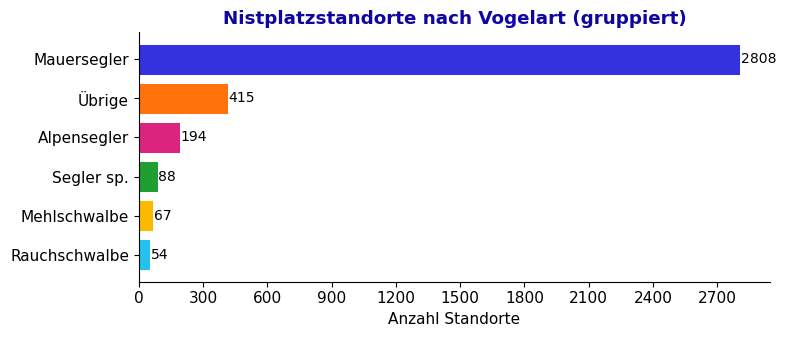

In [8]:
gruppen_counts = df['art_gruppe'].value_counts().sort_values()
farben = [ARTEN_FARBEN.get(art, '#999') for art in gruppen_counts.index]

fig, ax = plt.subplots(figsize=(8, 3.5))
bars = ax.barh(gruppen_counts.index, gruppen_counts.values, color=farben, edgecolor='white', linewidth=0.7)
ax.set_xlabel('Anzahl Standorte')
ax.set_title('Nistplatzstandorte nach Vogelart (gruppiert)', fontweight='bold', color=ZUERIBLAU)
for bar, val in zip(bars, gruppen_counts.values):
    ax.text(bar.get_width() + 3, bar.get_y() + bar.get_height() / 2, str(val), va='center', fontsize=10)
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
plt.tight_layout()
plt.show()

## 5. Verteilung nach Stadtkreis

In [9]:
kreis_df = df[df['kreis'] != 'unbekannt'].copy()
kreis_sort = sorted(kreis_df['kreis'].unique(), key=lambda k: int(''.join(c for c in k if c.isdigit()) or '0'))

pivot = pd.crosstab(kreis_df['kreis'], kreis_df['art_gruppe'])
art_order = [a for a in HAUPTARTEN + ['Übrige'] if a in pivot.columns]
pivot = pivot.reindex(index=kreis_sort, columns=art_order, fill_value=0)
pivot['Total'] = pivot.sum(axis=1)
pivot

art_gruppe,Mauersegler,Alpensegler,Segler sp.,Mehlschwalbe,Rauchschwalbe,Übrige,Total
kreis,,,,,,,
Kreis 1,108,36,6,0,1,30,181
Kreis 2,230,6,22,12,6,77,353
Kreis 3,416,19,11,8,11,46,511
Kreis 4,84,61,2,0,0,28,175
Kreis 5,53,24,9,0,0,20,106
Kreis 6,241,4,3,11,1,9,269
Kreis 7,165,12,4,4,3,36,224
Kreis 8,122,2,1,0,3,8,136
Kreis 9,373,11,7,2,2,42,437


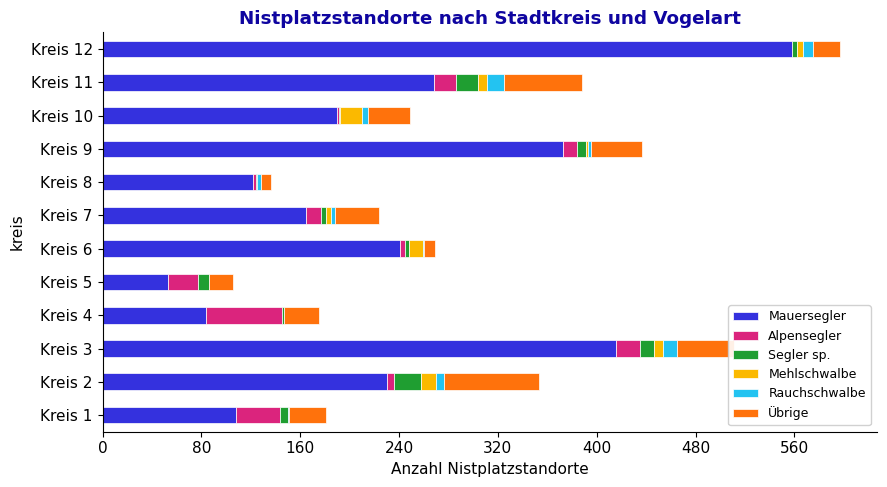

In [10]:
plot_pivot = pivot.drop(columns='Total')
colors = [ARTEN_FARBEN.get(a, '#999') for a in plot_pivot.columns]

fig, ax = plt.subplots(figsize=(9, 5))
plot_pivot.plot.barh(stacked=True, color=colors, edgecolor='white', linewidth=0.5, ax=ax)
ax.set_xlabel('Anzahl Nistplatzstandorte')
ax.set_title('Nistplatzstandorte nach Stadtkreis und Vogelart', fontweight='bold', color=ZUERIBLAU)
ax.legend(loc='lower right', fontsize=9, framealpha=0.9)
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
plt.tight_layout()
plt.show()

## 6. Top-Strassen

In [11]:
strassen = (
    df[df['strasse'] != '']
    .groupby('strasse')
    .agg(Standorte=('vogelarten', 'size'), Arten=('vogelarten', 'nunique'))
    .sort_values('Standorte', ascending=False)
    .head(20)
)
strassen.index.name = 'Strasse'
strassen

,Standorte,Arten
Strasse,,
Dreispitz,179,2
Bernhard-Jaeggi-Weg,123,2
Dübendorfstrasse,69,1
Burriweg,60,3
Saatlenstrasse,46,1
Langgrütstrasse,43,4
Kronwiesenstrasse,38,1
Altwiesenstrasse,33,1
Schaffhauserstrasse,28,5


## 7. KSO-Objekte

In [12]:
kso = df[df['kso_objekt'] == 'Ja'].copy()
print(f'{len(kso)} Standorte an KSO-Objekten ({len(kso)/total*100:.1f} %)')
print()
print('Verteilung nach Vogelart:')
print(kso['vogelarten'].value_counts().to_string())

541 Standorte an KSO-Objekten (14.9 %)

Verteilung nach Vogelart:
vogelarten
Mauersegler                                   386
Rauchschwalbe                                  37
Alpensegler                                    20
Mehlschwalbe                                   19
Mauersegler, Segler sp.                        12
Turmfalke                                      11
Alpensegler, Mauersegler                        9
Segler sp.                                      8
Mauersegler, Mehlschwalbe                       4
Mehlschwalbe, Rauchschwalbe                     4
andere Vogelart, Mauersegler                    4
Mauersegler, unbekannte Art                     4
Rauchschwalbe, Schleiereule                     2
Mauersegler, Rauchschwalbe                      2
Rauchschwalbe, Schleiereule, Turmfalke          2
Dohle, Turmfalke                                1
Alpensegler, Dohle, Segler sp., Turmfalke       1
Alpensegler, Dohle, Mauersegler, Turmfalke      1
Alpensegler, Dohle, Mau

## 8. Datenqualität

In [13]:
print('Fehlende Werte:')
for col in ['vogelarten', 'adresse', 'kso_objekt']:
    leer = df[col].isna().sum() + (df[col] == '').sum() + (df[col] == 'unbekannt').sum()
    print(f'  {col:15s}: {leer}')

print(f'\nKreis unbekannt: {(df["kreis"] == "unbekannt").sum()}')

print(f'\nKoordinaten-Bereich:')
print(f'  Lat: {df["lat"].min():.4f} – {df["lat"].max():.4f}')
print(f'  Lng: {df["lng"].min():.4f} – {df["lng"].max():.4f}')

dups = df.duplicated(subset=['adresse', 'vogelarten'], keep=False)
print(f'\nMögliche Duplikate (gleiche Adresse + Art): {dups.sum()}')
if dups.sum() > 0:
    print(df[dups][['adresse', 'vogelarten', 'kreis']].sort_values(['adresse', 'vogelarten']).to_string())

Fehlende Werte:
  vogelarten     : 0
  adresse        : 0
  kso_objekt     : 0

Kreis unbekannt: 0

Koordinaten-Bereich:
  Lat: 47.3232 – 47.4316
  Lng: 8.4661 – 8.6014

Mögliche Duplikate (gleiche Adresse + Art): 34
                                           adresse                vogelarten     kreis
107                                             ()               Mauersegler   Kreis 2
115                                             ()               Mauersegler   Kreis 6
123                                             ()               Mauersegler   Kreis 3
2741                                            ()               Mauersegler   Kreis 3
1686                            Agnesstrasse 3 (0)               Alpensegler   Kreis 4
1710                            Agnesstrasse 3 (0)               Alpensegler   Kreis 4
313                       Bachtobelstrasse 251 (0)             Rauchschwalbe   Kreis 3
314                       Bachtobelstrasse 251 (0)             Rauchschwalbe   Kreis 3


## 9. Veränderungen erkennen

Vergleiche die aktuellen KPIs mit bekannten Referenzwerten. Passe die Referenzwerte unten an, wenn du eine neue Baseline setzen willst.

In [14]:
REFERENZ = {
    'total': 863,
    'arten': 12,
    'top_art': 'Mauersegler',
    'kso': None,  # Noch kein Referenzwert — wird beim ersten Lauf gesetzt
}

aktuell = {
    'total': total,
    'arten': anzahl_arten,
    'top_art': top_art.index[0],
    'kso': kso_ja,
}

print('Vergleich mit Referenzwerten:')
for key, ref in REFERENZ.items():
    akt = aktuell[key]
    if ref is None:
        print(f'  {key:10s}: {akt} (kein Referenzwert)')
    elif akt == ref:
        print(f'  {key:10s}: {akt} ✓')
    else:
        diff = ''
        if isinstance(akt, (int, float)) and isinstance(ref, (int, float)):
            diff = f' (Δ {akt - ref:+d})'
        print(f'  {key:10s}: {akt} ← war {ref}{diff}  ⚠ GEÄNDERT')

Vergleich mit Referenzwerten:
  total     : 3626 ← war 863 (Δ +2763)  ⚠ GEÄNDERT
  arten     : 53 ← war 12 (Δ +41)  ⚠ GEÄNDERT
  top_art   : Mauersegler ✓
  kso       : 541 (kein Referenzwert)
